In [44]:
# 01 문제정의
# 02 데이터가져오기
# 03 EDA
# 04 데이터전처리
# 05 검증데이터 분할 및 학습
# 06 테스트 및 검증지표 확인
# 07 Model 내보내기 , 테스트파일 내보내기

In [45]:
#-----------------------------------
# 01 문제정의
#-----------------------------------

In [46]:
train

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,NCR06,12.500,Low Fat,0.006760,Household,42.8112,OUT013,1987,High,Tier 3,Supermarket Type1
1,FDW11,12.600,Low Fat,0.048741,Breads,60.4194,OUT013,1987,High,Tier 3,Supermarket Type1
2,FDH32,12.800,Low Fat,0.075997,Fruits and Vegetables,97.1410,OUT013,1987,High,Tier 3,Supermarket Type1
3,FDL52,6.635,Regular,0.046351,Frozen Foods,37.4506,OUT017,2007,Medium,Tier 2,Supermarket Type1
4,FDO09,13.500,Regular,0.125170,Snack Foods,261.4910,OUT013,1987,High,Tier 3,Supermarket Type1
...,...,...,...,...,...,...,...,...,...,...,...
6813,NCC54,17.750,Low Fat,0.097863,Health and Hygiene,239.3196,OUT049,1999,Medium,Tier 1,Supermarket Type1
6814,NCF19,13.000,Low Fat,0.035252,Household,48.0034,OUT018,2009,Medium,Tier 3,Supermarket Type2
6815,FDU11,4.785,Low Fat,0.092576,Breads,121.0098,OUT035,2004,Small,Tier 2,Supermarket Type1
6816,FDK14,6.980,Low Fat,0.041189,Canned,82.8934,OUT045,2002,Medium,Tier 2,Supermarket Type1


In [47]:
#-----------------------------------
# 02 데이터가져오기
#-----------------------------------

In [48]:
import pandas as pd
train = pd.read_csv('train.csv', low_memory=False) # 학습용 데이터 읽기 (low_memory=False: 타입 혼합 경고 방지)
test  = pd.read_csv('test.csv', low_memory=False)  # 학습용 데이터 읽기 (low_memory=False: 타입 혼합 경고 방지)
print('train:', train.shape, '| test:', test.shape)

train: (6818, 12) | test: (1705, 11)


In [49]:
#-----------------------------------
# 03 EDA
#-----------------------------------

In [50]:
train.head()


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,NCR06,12.500,Low Fat,0.006760,Household,42.8112,OUT013,1987,High,Tier 3,Supermarket Type1,639.1680
1,FDW11,12.600,Low Fat,0.048741,Breads,60.4194,OUT013,1987,High,Tier 3,Supermarket Type1,990.7104
2,FDH32,12.800,Low Fat,0.075997,Fruits and Vegetables,97.1410,OUT013,1987,High,Tier 3,Supermarket Type1,2799.6890
3,FDL52,6.635,Regular,0.046351,Frozen Foods,37.4506,OUT017,2007,NaN,Tier 2,Supermarket Type1,1176.4686
4,FDO09,13.500,Regular,0.125170,Snack Foods,261.4910,OUT013,1987,High,Tier 3,Supermarket Type1,3418.8830


In [51]:
test.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDO38,17.250,Low Fat,0.073251,Canned,76.4986,OUT017,2007,NaN,Tier 2,Supermarket Type1
1,FDO32,6.360,Low Fat,0.120544,Fruits and Vegetables,45.8060,OUT046,1997,Small,Tier 1,Supermarket Type1
2,FDT14,10.695,Regular,0.128247,Dairy,121.8440,OUT018,2009,Medium,Tier 3,Supermarket Type2
3,FDG50,7.405,Low Fat,0.015296,Canned,89.7146,OUT049,1999,Medium,Tier 1,Supermarket Type1
4,FDR11,10.500,Regular,0.142760,Breads,159.3578,OUT049,1999,Medium,Tier 1,Supermarket Type1


In [52]:
# train.describe()
train.describe(include="O")

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,6818,6818,6818,6818,4878,6818,6818
unique,1554,5,16,10,3,3,4
top,FDO19,Low Fat,Snack Foods,OUT046,Medium,Tier 3,Supermarket Type1
freq,9,4092,963,763,2228,2664,4474


In [53]:
# test.describe()
test.describe(include="O")

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,1705,1705,1705,1705,1235,1705,1705
unique,1077,5,16,10,3,3,4
top,DRD15,Low Fat,Fruits and Vegetables,OUT013,Medium,Tier 3,Supermarket Type1
freq,4,997,272,207,565,686,1103


In [54]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            6818 non-null   object 
 1   Item_Weight                5656 non-null   float64
 2   Item_Fat_Content           6818 non-null   object 
 3   Item_Visibility            6818 non-null   float64
 4   Item_Type                  6818 non-null   object 
 5   Item_MRP                   6818 non-null   float64
 6   Outlet_Identifier          6818 non-null   object 
 7   Outlet_Establishment_Year  6818 non-null   int64  
 8   Outlet_Size                4878 non-null   object 
 9   Outlet_Location_Type       6818 non-null   object 
 10  Outlet_Type                6818 non-null   object 
 11  Item_Outlet_Sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 639.3+ KB


In [55]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            1705 non-null   object 
 1   Item_Weight                1404 non-null   float64
 2   Item_Fat_Content           1705 non-null   object 
 3   Item_Visibility            1705 non-null   float64
 4   Item_Type                  1705 non-null   object 
 5   Item_MRP                   1705 non-null   float64
 6   Outlet_Identifier          1705 non-null   object 
 7   Outlet_Establishment_Year  1705 non-null   int64  
 8   Outlet_Size                1235 non-null   object 
 9   Outlet_Location_Type       1705 non-null   object 
 10  Outlet_Type                1705 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 146.7+ KB


In [56]:
train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,NCR06,12.500,Low Fat,0.006760,Household,42.8112,OUT013,1987,High,Tier 3,Supermarket Type1,639.1680
1,FDW11,12.600,Low Fat,0.048741,Breads,60.4194,OUT013,1987,High,Tier 3,Supermarket Type1,990.7104
2,FDH32,12.800,Low Fat,0.075997,Fruits and Vegetables,97.1410,OUT013,1987,High,Tier 3,Supermarket Type1,2799.6890
3,FDL52,6.635,Regular,0.046351,Frozen Foods,37.4506,OUT017,2007,NaN,Tier 2,Supermarket Type1,1176.4686
4,FDO09,13.500,Regular,0.125170,Snack Foods,261.4910,OUT013,1987,High,Tier 3,Supermarket Type1,3418.8830


In [57]:
num = train.select_dtypes('number')
num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Weight                5656 non-null   float64
 1   Item_Visibility            6818 non-null   float64
 2   Item_MRP                   6818 non-null   float64
 3   Outlet_Establishment_Year  6818 non-null   int64  
 4   Item_Outlet_Sales          6818 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 266.5 KB


In [58]:
num.corr()['Item_Outlet_Sales'].sort_values(ascending=False)

Item_Outlet_Sales            1.000000
Item_MRP                     0.566721
Item_Weight                  0.021243
Outlet_Establishment_Year   -0.051833
Item_Visibility             -0.124522
Name: Item_Outlet_Sales, dtype: float64

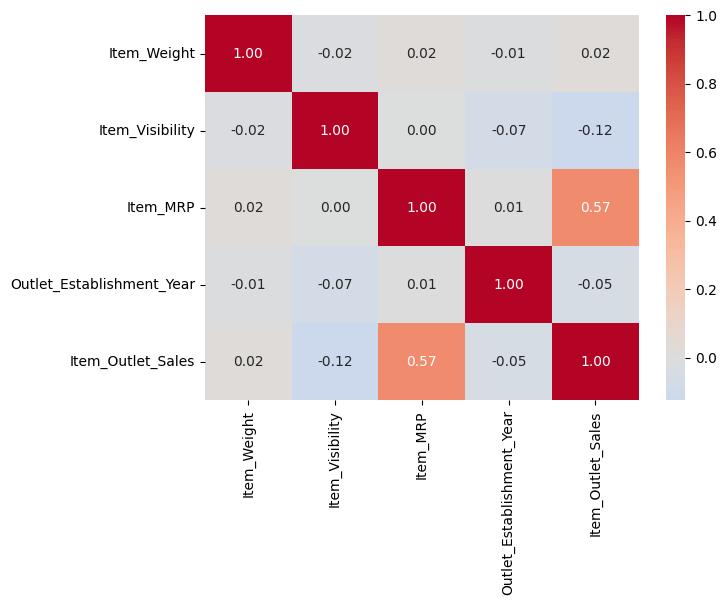

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.heatmap(num.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.show()

In [60]:
train.isnull().sum()

Item_Identifier                 0
Item_Weight                  1162
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1940
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [61]:
test.isnull().sum()

Item_Identifier                0
Item_Weight                  301
Item_Fat_Content               0
Item_Visibility                0
Item_Type                      0
Item_MRP                       0
Outlet_Identifier              0
Outlet_Establishment_Year      0
Outlet_Size                  470
Outlet_Location_Type           0
Outlet_Type                    0
dtype: int64

In [62]:
# 오염도 검증 LIB 보고서 사용 - (선택)
# pip install ydata-profiling
from ydata_profiling import ProfileReport
ProfileReport(train, title="Supermarket Report").to_file("report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 2534.07it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [63]:
#-----------------------------------
# 04 데이터전처리
#-----------------------------------

In [64]:
# cat_cols = [c for c in train.columns if train[c].dtype == 'object']
# print('범주형:', cat_cols)

null_series = train.isnull().sum()

null_object_series = null_series[(null_series>0) & (train.dtypes=='object')].index
null_object_series

Index(['Outlet_Size'], dtype='object')

In [65]:
# cat_cols_float = [c for c in train.columns if train[c].dtype == 'float64']
# print('수치형:', cat_cols_float)

null_float64_series = null_series[(null_series>0) & (train.dtypes=='float64')].index
null_float64_series

Index(['Item_Weight'], dtype='object')

In [66]:
num_cols = null_float64_series  # 수치형 데이터
cat_cols = null_object_series # 범주형 데이터

# 결측치 채우기 - 이 데이터는 결측이 0이라 실제로 채워지는 값이 없다.
# (결측이 있는 데이터라면 아래처럼 train 기준값으로 train/test를 함께 채운다)

for c in num_cols:
    m = train[c].median()            # train 기준 중앙값
    train[c] = train[c].fillna(m)
    test[c] = test[c].fillna(m)
    
for c in cat_cols:
    m = train[c].mode()[0]           # train 기준 최빈값
    train[c] = train[c].fillna(m)
    test[c] = test[c].fillna(m)
    
print('남은 결측치:', train.isnull().sum().sum(), test.isnull().sum().sum())

남은 결측치: 0 0


In [67]:
# train.info()
# test.info()
train.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [68]:
# y값 분리
y = train['Item_Outlet_Sales']   
y

0        639.1680
1        990.7104
2       2799.6890
3       1176.4686
4       3418.8830
          ...    
6813    3615.2940
6814     923.4646
6815    2530.7058
6816     818.9340
6817    1973.4312
Name: Item_Outlet_Sales, Length: 6818, dtype: float64

In [69]:
train = train.drop(columns=['Item_Outlet_Sales'])
train.shape

(6818, 11)

In [70]:
#-----------------------------------
# 05 검증데이터 분할 및 학습 - 단순선형회귀
# 06 테스트 및 검증지표 확인
#-----------------------------------


In [71]:
#------------------
# 단순 선형 회귀
#------------------

In [72]:
from sklearn.linear_model import LinearRegression
# X1 = train[['Item_MRP']]          # 특성 1개(2차원 형태로)
# 학습
lr1 = LinearRegression().fit(X1, y)
print('기울기:', round(lr1.coef_[0], 2), '| 절편:', round(lr1.intercept_, 2))
# 실측: 기울기 15.58, 절편 3.47 → 판매액 = 15.58 x MRP + 3.47 (MRP 1 오르면 판매액 15.58 증가)


NameError: name 'X1' is not defined

In [73]:
# 검증 데이터 분할 
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(X1, y, test_size=0.2, random_state=0)
lr = LinearRegression().fit(X_tr, y_tr)
pred = lr.predict(X_val)


NameError: name 'X1' is not defined

In [74]:
# 회귀 평가
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
rmse = np.sqrt(mean_squared_error(y_val, pred))
print('MAE :', round(mean_absolute_error(y_val, pred), 1))   # 약 800
print('RMSE:', round(rmse, 1))                       # 약 1060
print('R2  :', round(r2_score(y_val, pred), 4))      # 약 0.57 (0.5669)

MAE : 801.0
RMSE: 1060.3
R2  : 0.5669


In [75]:
#------------------
# 다중 선형 회귀
#------------------

In [76]:
## 전처리(원핫인코딩)

In [77]:
# X = train.drop(columns=['Item_Identifier', 'Outlet_Identifier'])
# X_test = test.drop(columns=['Item_Identifier', 'Outlet_Identifier'])

X = train.drop(columns=['Item_Identifier'])
X_test = test.drop(columns=['Item_Identifier'])

all_oh = pd.get_dummies(pd.concat([X, X_test], axis=0))
X = all_oh.iloc[:len(train)]
X_test = all_oh.iloc[len(train):]
print('결측:', X.isnull().sum().sum(), '| 컬럼:', X.shape[1])


결측: 0 | 컬럼: 45


In [78]:
# num = X.select_dtypes('number')
# X.corr()['Item_Outlet_Sales'].sort_values(ascending=False)

In [79]:
# 검증 데이터 분할 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=0)

# 학습 
lr = LinearRegression().fit(X_tr, y_tr)
pred = lr.predict(X_val)

In [80]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
rmse = np.sqrt(mean_squared_error(y_val, pred))
print('MAE :', round(mean_absolute_error(y_val, pred), 1))   # 약 800
print('RMSE:', round(rmse, 1))                       # 약 1060
print('R2  :', round(r2_score(y_val, pred), 4))      # 약 0.57 (0.5669)

MAE : 801.0
RMSE: 1060.3
R2  : 0.5669


In [81]:
# 모델 변경(LIGHTGBM)
#------------------

In [82]:
from sklearn.linear_model import LinearRegression

X3 = train[['Item_MRP','Outlet_Type','Outlet_Size']]          
X3_test = test[['Item_MRP','Outlet_Type','Outlet_Size']]        

# 전처리(원핫 인코딩)
all_oh = pd.get_dummies(pd.concat([X3, X3_test], axis=0))
X3 = all_oh.iloc[:len(train)]
X3_test = all_oh.iloc[len(train):]
print('결측:', X3.isnull().sum().sum(), '| 컬럼:', X3.shape[1])

# 검증 데이터 분할 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X3_tr, X3_val, y_tr, y_val = train_test_split(X3, y, test_size=0.2, random_state=0)

# 학습 
lr = LinearRegression().fit(X3_tr, y_tr)
pred = lr.predict(X3_val)

# 성능지표 확인
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
rmse = np.sqrt(mean_squared_error(y_val, pred))
print('MAE :', round(mean_absolute_error(y_val, pred), 1))   # 약 800
print('RMSE:', round(rmse, 1))                       # 약 1060
print('R2  :', round(r2_score(y_val, pred), 4))      # 약 0.57 (0.5669)

결측: 0 | 컬럼: 8
MAE : 798.6
RMSE: 1059.2
R2  : 0.5678


In [83]:
#------------------
# 모델변경
#------------------

In [84]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(objective='regression', n_estimators=500, learning_rate=0.05)
model.fit(X3_tr,y_tr)
pred = model.predict(X3_val)

# 성능지표 확인
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
mae  = mean_absolute_error(y_val, pred)
rmse = np.sqrt(mean_squared_error(y_val, pred))
r2   = r2_score(y_val, pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 269
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 8
[LightGBM] [Info] Start training from score 2202.546849
MAE  : 736.3228
RMSE : 1048.6811
R2   : 0.5764


In [87]:
import statsmodels.api as sm
Xc = sm.add_constant(train[['Item_MRP']])   # 절편항 추가
ols = sm.OLS(y, Xc).fit()
print(ols.summary().tables[1])              # coef, p-value 표
# 실측:  Item_MRP  coef 15.58  P>|t| 0.000  -> 유의미(가격은 판매액에 영향)
#        const     coef  3.47  P>|t| 0.934  -> 절편은 유의하지 않음
# p-value < 0.05면 통계적으로 유의미. (sklearn 기울기 15.58 = OLS coef 15.58 로 일치 확인)

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.4683     42.115      0.082      0.934     -79.090      86.027
Item_MRP      15.5781      0.274     56.788      0.000      15.040      16.116


In [36]:
#-----------------------------------
# 07 Model 내보내기 , 테스트파일 내보내기
#-----------------------------------